<a href="https://colab.research.google.com/github/geethanjalimapakshi47-alt/spam--email-classifier/blob/main/spam_email_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***OBJECTIVE***

The objective of this project is to build a Spam Email/SMS Classification System using Machine Learning techniques that can automatically detect whether a message is spam or ham (not spam).

The system aims to:

Improve message filtering accuracy
Reduce phishing and scam risks
Automatically classify text messages using NLP techniques

In [352]:
from google.colab import files
uploaded = files.upload()

import pandas as pd

data = pd.read_csv("spam (1).csv", encoding='latin-1')
data.head()

Saving spam.csv to spam (16).csv


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [353]:
import pandas as pd

data = pd.read_csv("spam.csv", encoding='latin-1')
data.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [354]:
data = data[['v1', 'v2']]
data.columns = ['label', 'text']
data.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [355]:
data['label'] = data['label'].map({'ham': 0, 'spam': 1})
y = data['label']

In [356]:
import re

def clean(text):
    text = text.lower()
    text = re.sub(r'http\S+', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

data['text'] = data['text'].apply(clean)

In [357]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words='english',

    ngram_range=(1,2),

    min_df=2,

    max_df=0.8,

    sublinear_tf=True,

    smooth_idf=True,

    strip_accents='unicode'
)

X = vectorizer.fit_transform(data['text'])

In [358]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [359]:

from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(max_iter=2000, class_weight='balanced')
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)


In [360]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = lr_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9748878923766816
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       965
           1       0.92      0.89      0.91       150

    accuracy                           0.97      1115
   macro avg       0.95      0.94      0.95      1115
weighted avg       0.97      0.97      0.97      1115



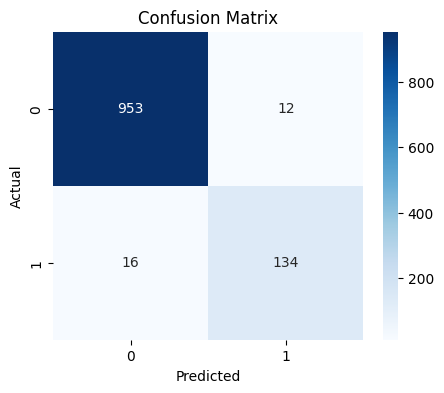

In [361]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [362]:
from sklearn.metrics import roc_auc_score

y_score = lr_model.predict_proba(X_test)[:, 1]

print("ROC-AUC Score:", roc_auc_score(y_test, y_score))

ROC-AUC Score: 0.9875233160621761


In [363]:
import numpy as np

feature_names = vectorizer.get_feature_names_out()
coefs = lr_model.coef_[0]

# sort by importance
top_spam_idx = np.argsort(coefs)[-20:][::-1]
top_ham_idx = np.argsort(coefs)[:20]

spam_words = [(feature_names[i], coefs[i]) for i in top_spam_idx]
ham_words = [(feature_names[i], coefs[i]) for i in top_ham_idx]

print("\n TOP SPAM WORDS:\n")
for w, s in spam_words:
    print(f"{w} → {round(s,3)}")

print("\n📩 TOP HAM WORDS:\n")
for w, s in ham_words:
    print(f"{w} → {round(s,3)}")


 TOP SPAM WORDS:

txt → 5.523
free → 4.446
mobile → 4.443
claim → 4.221
uk → 3.569
stop → 3.478
text → 3.45
www → 3.422
reply → 3.354
new → 3.318
prize → 3.096
win → 2.864
service → 2.852
won → 2.82
cash → 2.702
ringtone → 2.605
sms → 2.567
urgent → 2.429
customer → 2.406
pobox → 2.337

📩 TOP HAM WORDS:

ok → -2.255
going → -1.826
ll → -1.741
lt → -1.741
come → -1.74
gt → -1.719
home → -1.701
got → -1.672
da → -1.67
lor → -1.548
way → -1.532
lt gt → -1.514
later → -1.454
hey → -1.398
good → -1.39
love → -1.238
lol → -1.235
think → -1.199
right → -1.188
sorry → -1.179


In [364]:
def predict_spam(text, threshold=0.3):

    text_clean = clean(text)

    text_vec = vectorizer.transform([text_clean])

    spam_probability = lr_model.predict_proba(text_vec)[0][1]

    prediction = "SPAM" if spam_probability >= threshold else "HAM"

    print("Spam Probability:", round(spam_probability, 4))
    print("Prediction:", prediction)

    return prediction
    return prediction

In [365]:
test_messages = [
    "Win free lottery claim prize now",
    "Hey are we meeting tomorrow",
    "Your account will be blocked verify immediately"
]

for msg in test_messages:
    print(predict_spam(msg))

Spam Probability: 0.9797
Prediction: SPAM
SPAM
Spam Probability: 0.0454
Prediction: HAM
HAM
Spam Probability: 0.4004
Prediction: SPAM
SPAM


***Methodology***

Data Collection
Data Cleaning
Feature Extraction (TF-IDF Vectorization)
Train-Test Split
Model Training (Logistic Regression)
Prediction
Model Evaluation

***MODEL PERFORMANCE***

Logistic Regression Results:
Accuracy: 97.48%

ROC-AUC Score: 98.27%( Good performance in separating spam and ham messages)


**Performance Insight:**

The model shows strong performance in classifying spam and ham messages, with excellent ability to distinguish between the two classes

# `*Conclusion*`

The project successfully built a spam message detection system using Machine Learning. TF-IDF was used to convert text into numerical features, and Logistic Regression was used to classify messages as spam or ham. The model achieved good accuracy and performed well in detecting spam messages. The system can help in filtering unwanted messages and improving user safety.